#### 추론통계 (가설 검정과 통계적 검정)

표본 -> 모집단 추론

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

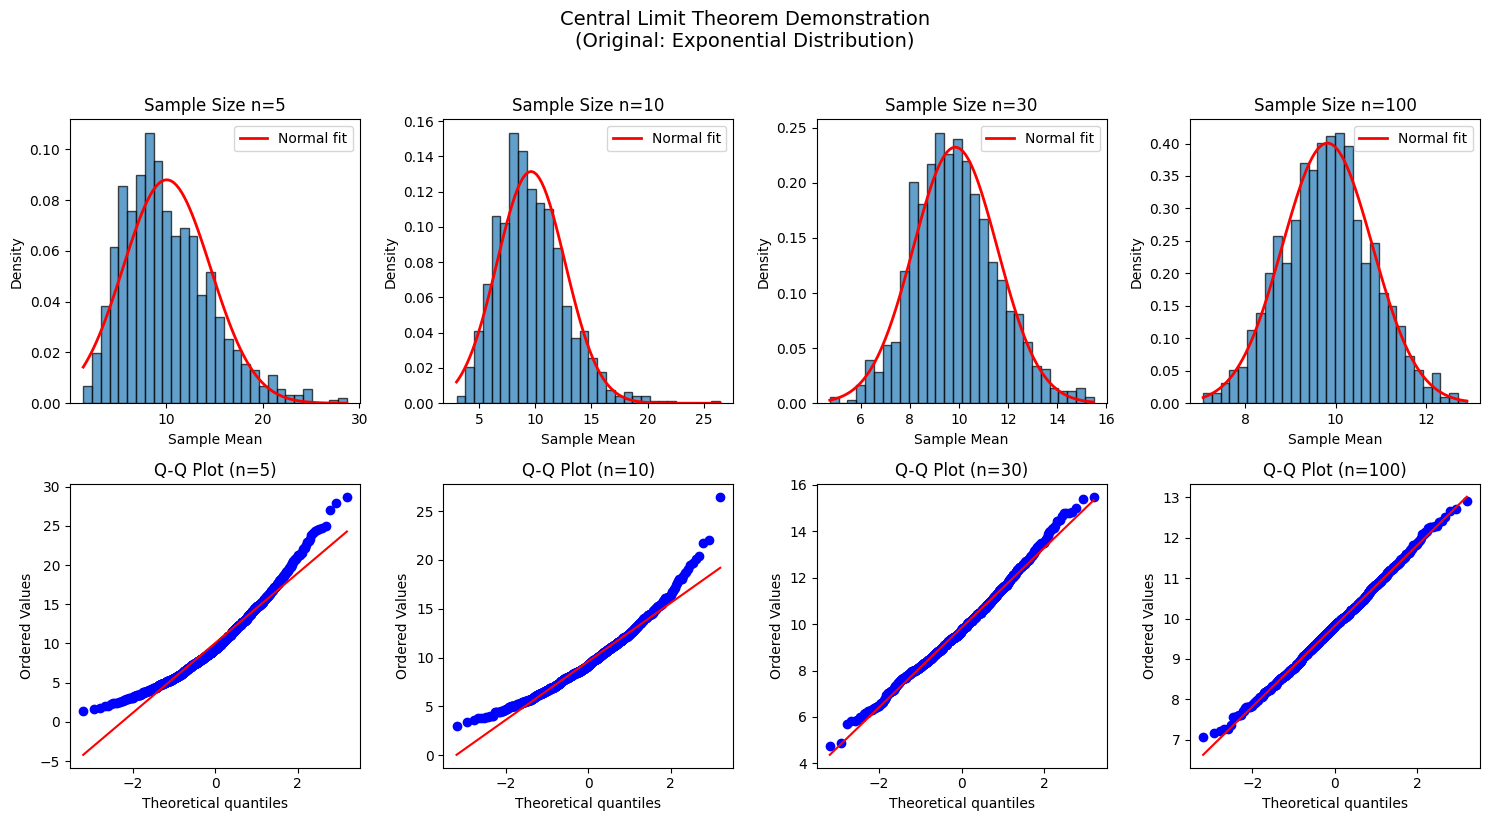

In [8]:
# 중심극한정리

# 원본 분포 (지수분포 - 비대칭분포)
population = np.random.exponential(scale=10, size=10000)

# 다양한 샘플 크기로 시뮬레이션
sample_sizes = [5, 10, 30, 100]
n_simulations = 1000

fig, axes = plt.subplots(2, len(sample_sizes), figsize=(15,8))

for idx, n in enumerate(sample_sizes):
    # 샘플 평균들 계산
    sample_means = []
    for _ in range(n_simulations):
        sample = np.random.choice(population, size=n, replace=True)
        sample_means.append(np.mean(sample))

    # 상단 : 샘플 평균의 분포
    axes[0, idx].hist(sample_means, bins=30, density=True, alpha=0.7, edgecolor='black')

    # 이론적 정규분포 오버레이
    mean_of_means = np.mean(sample_means)
    std_of_means = np.std(sample_means)
    x = np.linspace(min(sample_means), max(sample_means), 100)
    axes[0, idx].plot(x, stats.norm.pdf(x, mean_of_means, std_of_means), 'r-', lw=2, label='Normal fit')
    axes[0, idx].set_title(f"Sample Size n={n}")
    axes[0, idx].set_xlabel('Sample Mean')
    axes[0, idx].set_ylabel('Density')
    axes[0, idx].legend()

    # 하단 Q-Q plot
    stats.probplot(sample_means, dist="norm", plot=axes[1, idx])
    axes[1, idx].set_title(f"Q-Q Plot (n={n})")

# 원본 분포 표시
fig.suptitle('Central Limit Theorem Demonstration\n(Original: Exponential Distribution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# 고객 만족도 데이터의 신뢰구간 계산

customer_df = pd.read_csv("./customer_data.csv")
customer_df.head()

,customer_id,age,gender,purchase_amount,purchase_count,satisfaction_score,member_type
0,1,56,M,190.519862,5,8.361999,Bronze
1,2,69,M,68.348704,7,7.759631,Bronze
2,3,46,M,65.505514,4,7.936432,Bronze
3,4,32,F,89.748808,3,4.862233,Gold
4,5,60,M,174.114791,8,4.287733,Gold


In [13]:
# 100개 샘플
satisfaction_scores = customer_df['satisfaction_score'].values[:100]

# 기본 통계량
mean_score = np.mean(satisfaction_scores)
std_score = np.std(satisfaction_scores, ddof=1)         # 표본 표준편차
n = len(satisfaction_scores)
se = std_score / np.sqrt(n)                             # 표본 표준오차

print(f"=== 기본 통계량 ===")
print(f"샘플 크기: {n}")
print(f"평균: {mean_score:.2f}")
print(f"표준편차: {std_score:.2f}")
print(f"표준오차: {se:.3f}")

# 1. Z-분포를 사용한 신뢰구간 (큰 샘플 n>=30)
confidence_levels = [0.90, 0.95, 0.99]

print(f"\n=== Z-분포 신뢰구간 (n>=30) ===")
for confidence in confidence_levels:
    alpha = 1 - confidence
    z_critical = stats.norm.ppf(1- alpha/2)
    margin_of_error = z_critical * se
    ci_lower = mean_score - margin_of_error
    ci_upper = mean_score + margin_of_error
    print(f"{confidence*100:.0f}% CI: [{ci_lower:.3f}, {ci_upper:.3f}] (Z={z_critical:.3f}, ME=±{margin_of_error:.3f})")

# 2. t-분포를 사용한 신뢰구간 (작은 샘플에 더 적합)
print(f"\n=== t-분포 신뢰구간 ===")
for confidence in confidence_levels:
    alpha = 1 - confidence
    df = n - 1
    t_critical = stats.t.ppf(1-alpha/2, df)
    margin_of_error = t_critical * se
    ci_lower = mean_score - margin_of_error
    ci_upper = mean_score + margin_of_error

    print(f"{confidence*100:.0f}% CI: [{ci_lower:.3f}, {ci_upper:.3f}] (t={t_critical:.3f}, ME=±{margin_of_error:.3f})")


=== 기본 통계량 ===
샘플 크기: 100
평균: 6.79
표준편차: 1.47
표준오차: 0.147

=== Z-분포 신뢰구간 (n>=30) ===
90% CI: [6.552, 7.034] (Z=1.645, ME=±0.241)
95% CI: [6.506, 7.081] (Z=1.960, ME=±0.287)
99% CI: [6.415, 7.171] (Z=2.576, ME=±0.378)

=== t-분포 신뢰구간 ===
90% CI: [6.550, 7.037] (t=1.660, ME=±0.244)
95% CI: [6.502, 7.084] (t=1.984, ME=±0.291)
99% CI: [6.408, 7.178] (t=2.626, ME=±0.385)


#### 가설검정

1. 가설 설정
2. 유의수준 결정
3. 검정통계량 계산
4. 임계값 또는 p-value 계산
5. 의사결정 및 해석

In [15]:
# One-sample t-test 를 통한 직원 근무시간 검정
# 가설 : 직원들의 평균 근무시간이 40시간인지 검정

np.random.seed(42)
employee_hours = np.random.normal(42, 5, 50)

# 검정할 모집단 평균
population_mean = 40

sample_mean = np.mean(employee_hours)
sample_std = np.std(employee_hours, ddof=1)
n = len(employee_hours)

print("=== 직원 근무시간 One-Sample t-test ===")
print(f"귀무가설 (H0): u == q{population_mean} 시간")
print(f"대립가설 (H1): u != q{population_mean} 시간")
print(f"\n샘플 크기: {n}")
print(f"샘플 평균: {sample_mean:.2f} 시간")
print(f"샘플 표준편차: {sample_std:.2f} 시간")

# 직접 계산
t_statistic_manual = (sample_mean - population_mean) / (sample_std / np.sqrt(n))
df = n - 1
p_value_manual = 2 * (1- stats.t.cdf(abs(t_statistic_manual), df))

print(f"\n=== 수동 계산 결과 ===")
print(f"t-통계량: {t_statistic_manual:.4f}")
print(f"자유도: {df}")
print(f"p-value: {p_value_manual:.4f}")

# scipy.stats.ttest_1samp 사용
t_statistic, p_value = stats.ttest_1samp(employee_hours, population_mean)

print(f"\n=== scipy.stats 결과 ===")
print(f"t-통계량: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

# 유의수준별 결론
alpha_levels = [0.01, 0.05, 0.10]
for alpha in alpha_levels:
    if p_value < alpha:
        conclusion = "귀무가설 기각 (평균이 40시간과 다름)"
    else:
        conclusion = "귀무가설을 기각하지 못함"
    print(f"\n 알파 = {alpha}: {conclusion}")

# 효과 크기
cohens_d = (sample_mean - population_mean) / sample_std
print(f"\n효과 크기 (Cohen's d): {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect_size = "매우 작음"
elif abs(cohens_d) < 0.5:
    effect_size = "작음"
elif abs(cohens_d) < 0.8:
    effect_size = "중간"
else:
    effect_size = "큼"
print(f"효과 크기 해석: {effect_size}")

=== 직원 근무시간 One-Sample t-test ===
귀무가설 (H0): u == q40 시간
대립가설 (H1): u != q40 시간

샘플 크기: 50
샘플 평균: 40.87 시간
샘플 표준편차: 4.67 시간

=== 수동 계산 결과 ===
t-통계량: 1.3218
자유도: 49
p-value: 0.1924

=== scipy.stats 결과 ===
t-통계량: 1.3218
p-value: 0.1924

 알파 = 0.01: 귀무가설을 기각하지 못함

 알파 = 0.05: 귀무가설을 기각하지 못함

 알파 = 0.1: 귀무가설을 기각하지 못함

효과 크기 (Cohen's d): 0.187
효과 크기 해석: 매우 작음


In [22]:
# 독립표본 t-test (Two-Sample t-test)
# A/B 테스트 : 새로운 UI가 구매금액에 영향을 미쳤는가?

np.random.seed(42)

# A/B 그룹 데이터 생성
# 그룹A (기존UI): 평균 100, 표준편차 30
group_A = np.random.normal(100, 30, 100)
# 그룹B (새로운UI): 평균 110, 표준편차 35
group_B = np.random.normal(110, 35, 120)

# 기본통계량
mean_A, std_A, n_A = np.mean(group_A), np.std(group_A, ddof=1), len(group_A)
mean_B, std_B, n_B = np.mean(group_B), np.std(group_B, ddof=1), len(group_B)

print("=== A/B 테스트: 구매금액 비교 ===")
print(f"귀무가설 (H0): uA = uB (두 그룹의 평균 구매금액이 같다)")
print(f"대립가설 (H1): uA ≠ uB (두 그룹의 평균 구매금액이 다르다)")

print(f"\n그룹 A (기존 UI):")
print(f"  샘플크기: {n_A}")
print(f"  평균: ${mean_A:.2f}")
print(f"  표준편차: ${std_A:.2f}")

print(f"\n그룹 B (새로운 UI):")
print(f"  샘플크기: {n_B}")
print(f"  평균: ${mean_B:.2f}")
print(f"  표준편차: ${std_B:.2f}")

print(f"\n평균 차이: ${mean_B - mean_A:.2f}")

# 1. 등분산 검정 (Levene's test)
levene_stat, levene_p = stats.levene(group_A, group_B)
print(f"\n=== 등분산 검정 ===")
print(f"검정 통계량: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")
if levene_p > 0.05:
    print("결론: 등분산 가정 만족 (equal_var=True)")
    equal_var = True
else:
    print("결론: 등분산 가정 위반 (equal_var=False, Welch's t-test 사용)")
    equal_var = False

# 독립표본 t-test
t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=equal_var)

print(f"\n=== 독립표본 t-test 결과 ===")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 유의수준별 결론
alpha = 0.05
if p_value < alpha:
    conclusion = "귀무가설 기각 (p={p_value:.4f} < 알파={alpha})"
    recommendation = "새로운 UI가 구매금액에 유의미한 영향을 미침"
else:
    conclusion = f"귀무가설 채택 (p={p_value:.4f} >= 알파={alpha})"
    recommendation = "새로운 UI가 구매금액에 유의미한 영향을 미치지 않음"

print(f"\n결론: {conclusion}")
print(f"권고사항 {recommendation}")


=== A/B 테스트: 구매금액 비교 ===
귀무가설 (H0): uA = uB (두 그룹의 평균 구매금액이 같다)
대립가설 (H1): uA ≠ uB (두 그룹의 평균 구매금액이 다르다)

그룹 A (기존 UI):
  샘플크기: 100
  평균: $96.88
  표준편차: $27.25

그룹 B (새로운 UI):
  샘플크기: 120
  평균: $113.12
  표준편차: $34.38

평균 차이: $16.24

=== 등분산 검정 ===
검정 통계량: 3.4952
p-value: 0.0629
결론: 등분산 가정 만족 (equal_var=True)

=== 독립표본 t-test 결과 ===
t-통계량: -3.8269
p-value: 0.0002

결론: 귀무가설 기각 (p={p_value:.4f} < 알파={alpha})
권고사항 새로운 UI가 구매금액에 유의미한 영향을 미침
